# Problem Statement 

Manual monitoring of land use (forests, glaciers, urban areas, water bodies)
from large-scale image data such as satellite or drone imagery is time-consuming
and inefficient.

There is a need for an automated system that can classify natural scenes
accurately to support environmental monitoring, urban planning,
and climate change analysis.

# proposed soltuion 
We propose a Convolutional Neural Network (CNN)-based image classification system
that automatically categorizes input images into six classes:
buildings, forest, glacier, mountain, sea, and street.

The model uses deep feature extraction through multiple convolutional layers,
followed by a fully connected network to perform classification.

This system can assist in:
- Monitoring deforestation
- Tracking glacier changes
- Identifying urban expansion
- Analyzing coastal regions


# Implementation

In [115]:
!pip install torchinfo

In [126]:
# Import Required Libraries

import os # file handling
import numpy as np
import matplotlib.pyplot as plt

import torch # Main PyTorch library
import torch.nn as nn # Contains neural network components
import torch.optim as optim # contains optimizers like SGD, Adam 

from torch.utils.data import DataLoader
from torchvision import datasets, transforms # transforms = data preprocessing ( normalization, dimension reduction etc... )
from torchinfo import summary # to print model summary

In [127]:
# Updated Data Transformations

train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),  # 🔥 increased
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 🔥 NEW
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [128]:
train_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
test_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"

# ImageFolder will read image, assign lables and then apply transformations 

# Load dataset
train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=train_transforms)


test_dataset = datasets.ImageFolder(root=test_dir,
                                    transform=test_transforms)

In [129]:
print(train_dataset.classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [130]:
import torch
print(torch.cuda.is_available())

True


In [131]:
# Loading the dataset
# instead of loading all at once DataLoader help us to load in batch and also provide shuffling capability 

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=128,
                          shuffle=True)
# Shuffle will randomly shuffle data to every epoch ( improves generalization )

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=128,
                         shuffle=False)

In [143]:
# Check one batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

# output shows 
# 32 batch then 3 channels and then size of image (150x150)


torch.Size([128, 3, 150, 150])
torch.Size([128])


In [145]:
# Updated CNN Model

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolutional Blocks

        # Block 1: 3 → 32
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 32 → 64
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 64 → 128
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4: 128 → 256
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Fully Connected (reduced size)
        self.fc1 = nn.Linear(256 * 9 * 9, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):

        # Conv Blocks + Dropout
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

- Why Relu ? :- Adds Non Linearity 
- Randomly Dropping Neurons in Fully Connected to prevent from overfitting
- Batch Normalization will normalize output of conv into normal distribution and this will help in faster training
- Max Pool Layer is used to reduce the size and pick the important pixels only from feature map

In [146]:
# Device (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = CNNModel().to(device)

# we used Cross Entropyloss because it is classification problem 
criterion = nn.CrossEntropyLoss()

# adam optimizer because it provide adaptive learning rate + momentum
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [147]:
# Verifying architecture

summary(model, input_size=(128, 3, 150, 150))

Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [128, 6]                  --
├─Conv2d: 1-1                            [128, 32, 150, 150]       896
├─BatchNorm2d: 1-2                       [128, 32, 150, 150]       64
├─MaxPool2d: 1-3                         [128, 32, 75, 75]         --
├─Conv2d: 1-4                            [128, 64, 75, 75]         18,496
├─BatchNorm2d: 1-5                       [128, 64, 75, 75]         128
├─MaxPool2d: 1-6                         [128, 64, 37, 37]         --
├─Conv2d: 1-7                            [128, 128, 37, 37]        73,856
├─BatchNorm2d: 1-8                       [128, 128, 37, 37]        256
├─MaxPool2d: 1-9                         [128, 128, 18, 18]        --
├─Conv2d: 1-10                           [128, 256, 18, 18]        295,168
├─BatchNorm2d: 1-11                      [128, 256, 18, 18]        512
├─MaxPool2d: 1-12                        [128, 256, 9, 9]          -

In [148]:

# Training Loop

num_epochs = 7

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/7] Loss: 1.4590, Accuracy: 46.99%
Epoch [2/7] Loss: 1.0125, Accuracy: 59.23%
Epoch [3/7] Loss: 0.9133, Accuracy: 64.08%
Epoch [4/7] Loss: 0.8589, Accuracy: 66.81%
Epoch [5/7] Loss: 0.8007, Accuracy: 69.26%
Epoch [6/7] Loss: 0.7589, Accuracy: 71.59%
Epoch [7/7] Loss: 0.7287, Accuracy: 72.92%


In [149]:

# Evaluate Model on Test Data

model.eval()  # set model to evaluation mode 
# it turn off dropout randomness
# batchnorm training behavior
correct = 0
total = 0

with torch.no_grad():  # no gradient calculation (faster + memory efficient)
    for images, labels in test_loader:

        # Move to GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Final accuracy
test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 80.77%


The model achieves very Less accuracy on both training and test datasets due to the distinct visual differences between classes and Low Training Epocs.

it seems underfitting but we need to run more epoch for proper results

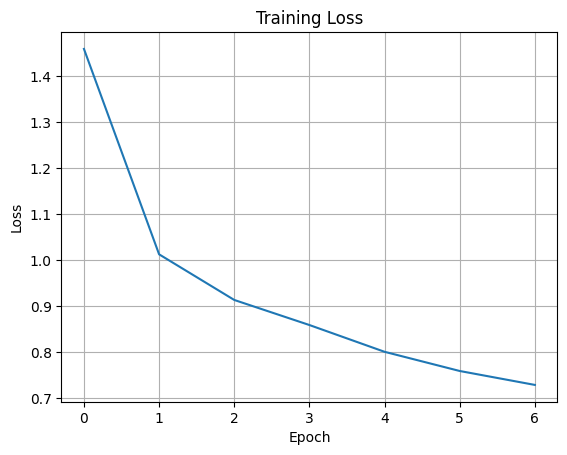

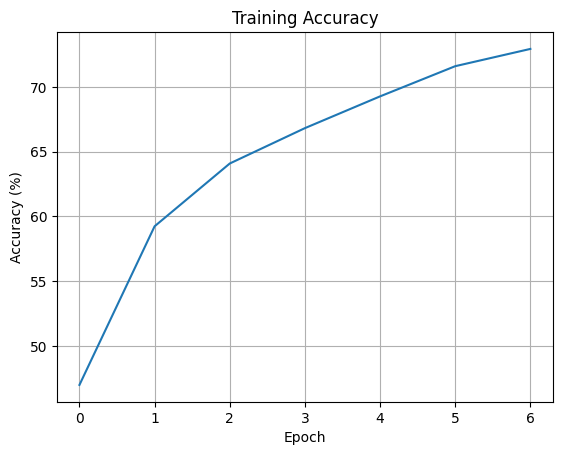

In [150]:
# Plot Loss
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

The model converges very quickly, which may indicate high model capacity or dataset simplicity.

In [151]:

# Precision, Recall, F1 Score


from sklearn.metrics import classification_report
import pandas as pd

# Generate report
report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)

# Convert to DataFrame
df = pd.DataFrame(report).transpose()

print(df)

              precision    recall  f1-score      support
buildings      0.675900  0.558352  0.611529   437.000000
forest         0.944882  0.759494  0.842105   474.000000
glacier        0.665493  0.341772  0.451613   553.000000
mountain       0.486705  0.801905  0.605755   525.000000
sea            0.390977  0.305882  0.343234   510.000000
street         0.623944  0.884232  0.731627   501.000000
accuracy       0.604333  0.604333  0.604333     0.604333
macro avg      0.631317  0.608606  0.597644  3000.000000
weighted avg   0.626258  0.604333  0.591918  3000.000000


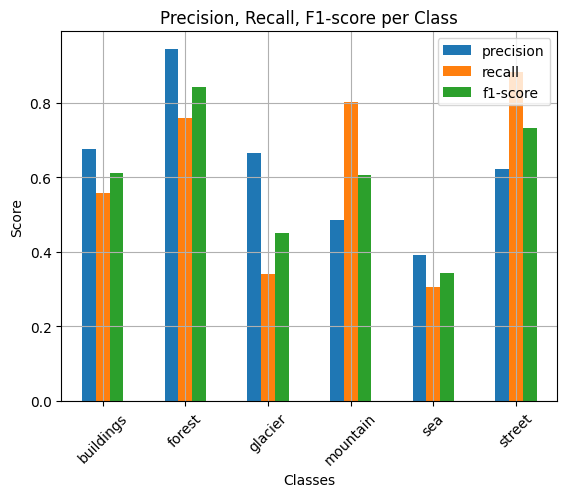

In [152]:
df_classes = df.iloc[:-3]  # remove avg rows

df_classes[['precision', 'recall', 'f1-score']].plot(kind='bar')

plt.title("Precision, Recall, F1-score per Class")
plt.xlabel("Classes")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

The model demonstrates varied performance across different classes, as seen from the precision, recall, and F1-score values. Classes such as forest and street achieve relatively high scores due to their distinct visual patterns, making them easier for the CNN to learn and classify. In contrast, classes like glacier and sea show lower recall and F1-scores, indicating that the model struggles to correctly identify all instances of these categories, likely due to visual similarity with other classes such as mountains or open landscapes. The difference between precision and recall in some classes suggests that the model either over-predicts or misses certain categories, reflecting inter-class confusion. Overall, the model performs reasonably well, but the variation in metrics highlights the need for improvements such as better data augmentation, train for more epochs to enhance generalization and reduce misclassification.
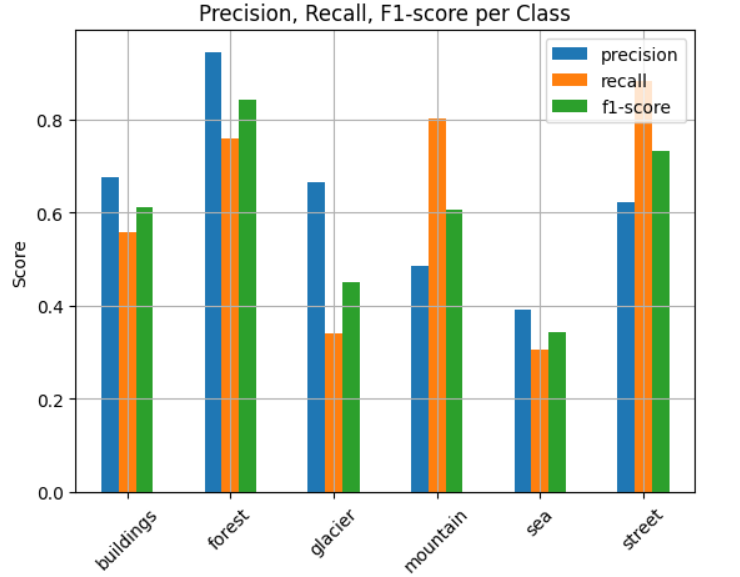

In [155]:
torch.save(model.state_dict(), "model.pth")